In ons expiriment gaan wij een koperen plaat laten zweven door eronder magneten in een bepaalde opstelling te laten draaien.

<img src="idee.jpeg" width="25%">

Om dit te kunnen simuleren worden er g.......... eerst onze aanpak daarna formules



1. Magneet:
om een magneet te benaderen verdelen we op het voorvlak en het achtervlak perfecte dipolen. De totale magnetische kracht wordt verdeeld onder de magneten. Hierdoor als het aantal dipolen verhoogd, komt er een steeds betere benadering van de magneet.

2. samenstelling magneten:

2.1 Configuratie:

Vervolgens verdelen we de mageneten op een cirkel. De orientatie van de magneten wordt bepaal door de plek op de cirkel.

2.2 Hallbach array:

Een Hallbach array is een bepaalde configuratie van magneten die het magneetveld meer kan concentreren op een bepaalde hoogte van de magneten. In onze simulatie gaan wij kijken bij welke hoogt dit optimaal is.


3. koperen plaat:
De koperen plaat verdelen we ook onder in punten die de flux meten


4. draaing van de magneten
    Om de draain van de magneten simpel te kunnen simuleren gebruiken wij. is onze simulatie radiaal symetrisch






Wiskunde:

1. Magneet

formule Bveld perfecte dipool, multipoolexapnsie, dipoolterm blijft:




2. Configuratie:

<img src="Cirkelverdeling.jpeg" width="25%">



In [3]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt


Student 1: [Nina Gumbs], [6552544]
Student 2: [Luuk van Dijk], [651702]
Student 3: [Jens Groen], [6353991]

In [4]:
#Constanten
mu0 = 4*np.pi*10**-7

Dipool benadering Magneetveld circulaire halbach array

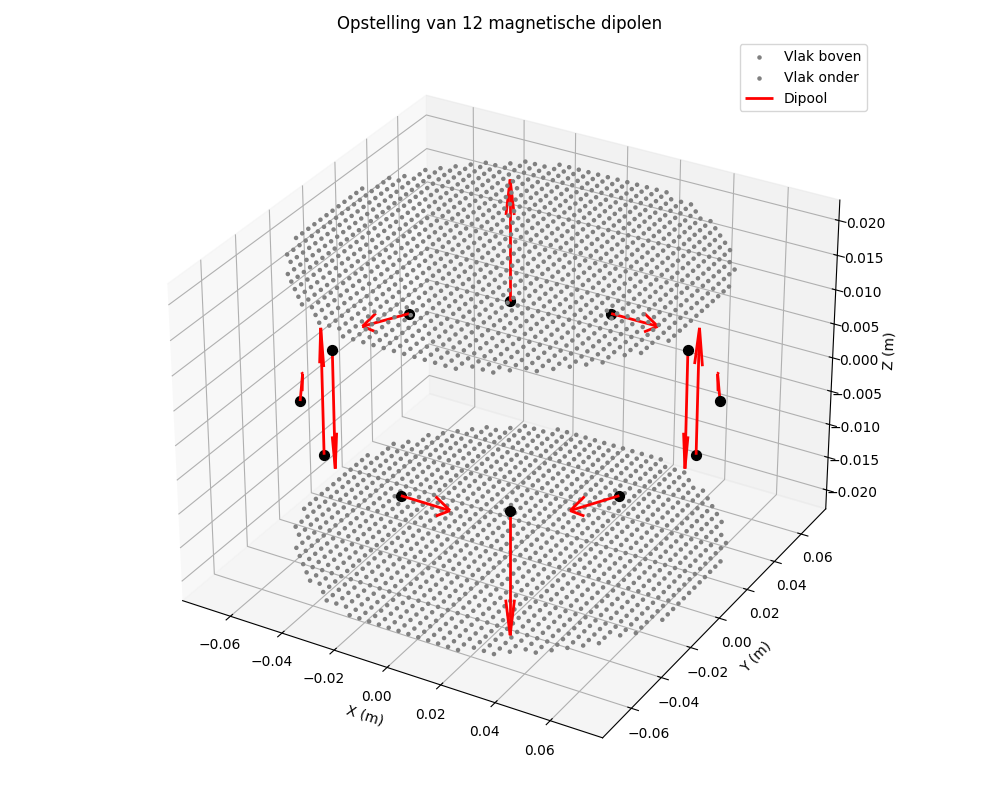

In [13]:
#########inputs#########

# aantal magneten
N = 12



#Magneet waardes
rmag = 18*10**-3
Amag = np.pi *rmag**2
hmag =  3*10**-3
Br = 1.265 # N35 ~ N45 
p = 3 #draaingrichting en snelheid van hoek van de magneten


# radius
r    = N*rmag/np.pi

#Configuratie van de magneten
configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal",
}

configuratie = 0 
################flux_kwadraat################

#flux_kwadraatvlak 1
xo1 = 0
yo1 = 0
n1 = 40  # grid resolution
width1 = r*2.1
z_plane1 = 0.02

#flux_kwadraatvlak 2 gespiegeld op het x-y vlak
xo2 = xo1
yo2 = yo1
n2 = n1  # grid resolution
width2 = width1
z_plane2 = -z_plane1




##############Berekeningen##########


conf = configuratie_namen[configuratie]
def m(theta,conf,p):
    V = Amag * hmag
    m = (Br * V)/mu0*Magnetenrichting(theta,conf,p)
    return m

def Magnetenrichting(theta,conf,p):
    alpha = p * theta
    z_hat = np.array([0, 0, 1]) 
    r_hat = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    if conf == "Halbach":
        phi = np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat 
    if conf == "Parallel":
        phi = z_hat
    if conf == "Radiaal":
        phi = r_hat
    if conf == "Chat Halbach":
        phi = np.sin(alpha) * r_hat + np.cos(alpha) * z_hat
    return phi

def Magnetenpositie(r,theta):
    z = 0
    rdak = np.array([r*np.cos(theta),r*np.sin(theta),z])
    return rdak

def Bveld(r,rpunt,conf,p,N):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2*np.pi*i/N
        mag = m(theta,conf,p)
        R = rpunt - Magnetenpositie(r,theta) #vector van magneet naar meetpunt
        Rdakje = R/np.linalg.norm(R)
        B = mu0/(4*np.pi*np.linalg.norm(R)**3)*(3*np.dot(mag, Rdakje)*Rdakje - mag) 
        Btot = B + Btot
    return Btot

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    punten = []
    for xi in x:
        for yi in y:
            # Alleen punten binnen de cirkel
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                rpunt = np.array([xi, yi, z_plane])
                punten.append((rpunt, dx, dy))
    
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r, rpunt, conf, p, N)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak_cirkel(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak_cirkel(width2, z_plane2,n2, xo2, yo2)

# print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_boven,"Parallel", p,N), "Wb")
# print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_onder,"Parallel", p,N), "Wb")
# print("flux_kwadraat boven, "+ conf +", magneten:", flux_kwadraat(vlak_boven,conf, p,N), "Wb")
# print("flux_kwadraat onder, " + conf +  ", magneten:", flux_kwadraat(vlak_onder,conf,p,N), "Wb")




#######plotting########

def plot_vlak(ax, punten, color='cyan', alpha=1, label=''):
    """Plot de gridpunten van maak_vlak_cirkel als stippen in 3D."""
    xs = [p[0][0] for p in punten]
    ys = [p[0][1] for p in punten]
    zs = [p[0][2] for p in punten]
    ax.scatter(xs, ys, zs, color=color, alpha=alpha, s=5, label=label)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Vlak
plot_vlak(ax, vlak_boven, color='grey',   label='Vlak boven')
plot_vlak(ax, vlak_onder, color='gray', label='Vlak onder')



#magneten
for i in range(N):
    theta    = 2 * np.pi * i / N
    pos      = Magnetenpositie(r, theta)
    richting = Magnetenrichting(theta, conf, p)

    # Pijl
    ax.quiver(*pos, *richting, length=rmag, color='red',
              linewidth=2, label='Dipool' if i == 0 else "")

    ax.scatter(*pos, color='black', s=50, zorder=5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
#########  INPUTS Magneetring  ##########

#Aantal magneten#
N = 12

p = 3 #rotatiesnelheid magneten


#Configuratie van de magneten

configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
}
configuratie = 1

# Magneet waardes
rmag = 15*10**-3/2 # radius magneet
hmag = 8*10**-3/2 # hoogte magneet

nmag = 10 # resolutie grid magneet

Br = 1.265 #magneet sterkte N35 ~ N45 

r = N*rmag/np.pi # radius ring

################  fluxvlak inputs  ################

#fluxvlak 1

xo1 = 0
yo1 = 0
n1 = 40  # grid resolutie
width1 = r*2.1
z_plane1 = -0.02

# #fluxvlak 2

# xo2 = xo1
# yo2 = yo1
# n2 = n1  # grid resolutie
# width2 = width1
# z_plane2 = -z_plane1

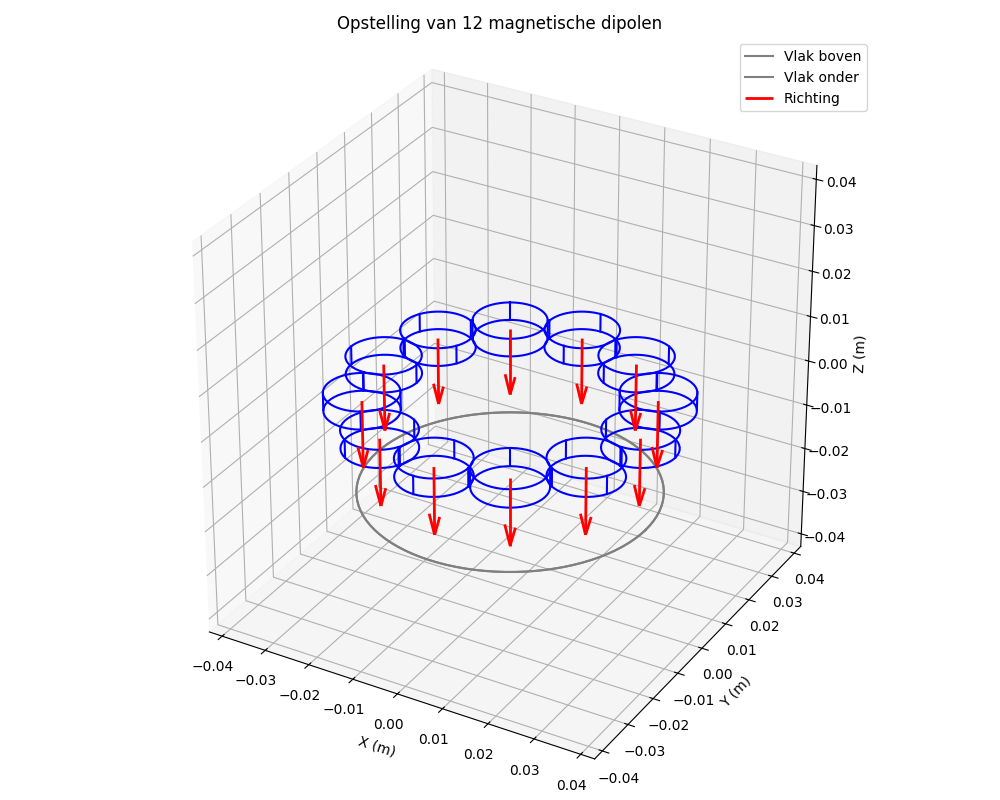

In [15]:
##############Berekeningen##########

Amag = np.pi * rmag**2   # oppervlakte van de cirkelvormige magneet

conf = configuratie_namen[configuratie]

zmag = hmag/2


def cilindrisch(theta):
    """cilindrisch coordinatenstelsel."""

    r_hat   = np.array([ np.cos(theta), np.sin(theta), 0])
    phi_hat = np.array([-np.sin(theta), np.cos(theta), 0])
    z_hat   = np.array([0, 0, 1])
    return r_hat, phi_hat, z_hat


def Lokaalstelsel(theta, conf, p):
    """Lokaal coordinatenstelsel"""
    r_hat,phi_hat,z_hat = cilindrisch(theta)

    alpha = p * theta

    """Halbach"""
    if conf == "Halbach":

        """Magneetrichting"""
        nu_hat = np.sin(alpha) * phi_hat + np.cos(alpha) * z_hat 


        """Lokaal Vlak"""
        t_hat = r_hat
        s_hat = np.cross(nu_hat, t_hat)
        s_hat = s_hat / np.linalg.norm(s_hat)  ###########   nog checken


    """Parallel"""
    if conf == "Parallel":
        nu_hat = -z_hat
        s_hat   = r_hat
        t_hat   = phi_hat

    return nu_hat, s_hat, t_hat


def Magnetenpositiecirkel(r, rmag, theta, zmag, nmag, conf, p):

    dipoolposities = []
    centrum = np.array([r * np.cos(theta), r * np.sin(theta), 0])  # ← toegevoegd

    nu_hat, s_hat, t_hat = Lokaalstelsel(theta, conf, p)

    for cirkel in [maak_vlak_cirkel(rmag*2, +zmag, nmag)[0],
                   maak_vlak_cirkel(rmag*2, -zmag, nmag)[0]]:
        for (lokaal, dx, dy) in cirkel:
            punt = centrum + lokaal[0]*t_hat + lokaal[1]*s_hat + lokaal[2]*nu_hat
            dipoolposities.append((punt, dx, dy))
    return dipoolposities


##### magnetatie ####
def m(theta, conf, p, n_punten):

    nu_hat, s_hat, t_hat = Lokaalstelsel(theta,conf,p)

    V_totaal = Amag * zmag * 2
    V_per_punt = V_totaal / n_punten
    m = (Br * V_per_punt) / mu0 * nu_hat
    return m


def Bveld(r, rpunt, conf, p, N, rmag, zmag, nmag):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2 * np.pi * i / N
        posities = Magnetenpositiecirkel(r, rmag, theta, zmag, nmag)
        n_punten = len(posities)                  
        mag = m(theta, conf, p, n_punten)
        
        for (magpunt, dt, ds) in posities:
            R = rpunt - magpunt
            norm_R = np.linalg.norm(R)
            if norm_R < 1e-10:
                continue
            Rdak = R / norm_R
            B = mu0 / (4 * np.pi * norm_R**3) * (3 * np.dot(mag, Rdak) * Rdak - mag)
            Btot += B
    return Btot

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    punten = []
    for xi in x:
        for yi in y:
            # Alleen punten binnen de cirkel
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                rpunt = np.array([xi, yi, z_plane])
                punten.append((rpunt, dx, dy))
    
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N,rmag,zmag,nmag):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r,rpunt,conf,p,N,rmag,zmag,nmag)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak_cirkel(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak_cirkel(width2, z_plane2,n2, xo2, yo2)


#######plotting########
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


def plot_vlak(ax, z_plane, r_max, color='grey', label=''):
    hoeken = np.linspace(0, 2*np.pi, 100)
    x = r_max * np.cos(hoeken)
    y = r_max * np.sin(hoeken)
    z = np.full_like(x, z_plane)
    ax.plot(x, y, z, color=color, label=label)

plot_vlak(ax, z_plane1,  width1/2, color='grey', label='Vlak boven')
plot_vlak(ax, z_plane2, width1/2, color='gray',  label='Vlak onder')




def plot_magneet_cilinder(ax, centrum, theta, rmag, zmag, color='blue'):
    nu_hat, s_hat, t_hat = Lokaalstelsel(theta, conf, p)  # ← theta als arg
    hoeken = np.linspace(0, 2*np.pi, 50)

    for teken in (+1, -1):
        cirkel = np.array([
            centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + teken*zmag*nu_hat
            for a in hoeken
        ])
        ax.plot(cirkel[:,0], cirkel[:,1], cirkel[:,2], color=color)

    for a in [0, np.pi/2, np.pi, 3*np.pi/2]:
        boven = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + zmag*nu_hat
        onder = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat - zmag*nu_hat
        ax.plot([boven[0],onder[0]], [boven[1],onder[1]], [boven[2],onder[2]], color=color)


# Plot-loop
for i in range(N):
    theta   = 2 * np.pi * i / N          # ← eerst theta
    centrum = np.array([r*np.cos(theta), r*np.sin(theta), 0])
    nu_hat, s_hat, t_hat = Lokaalstelsel(theta, conf, p)

    plot_magneet_cilinder(ax, centrum, theta, rmag, zmag)
    ax.quiver(*centrum, *nu_hat, length=rmag*2, color='red',
              linewidth=2, label='Richting' if i == 0 else "")
    


def set_axes_gelijk(ax, bereik):
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlim3d(-bereik, bereik)
    ax.set_ylim3d(-bereik, bereik)
    ax.set_zlim3d(-bereik, bereik)

set_axes_gelijk(ax, bereik=1.5*r)  # pas aan naar jouw situatie
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


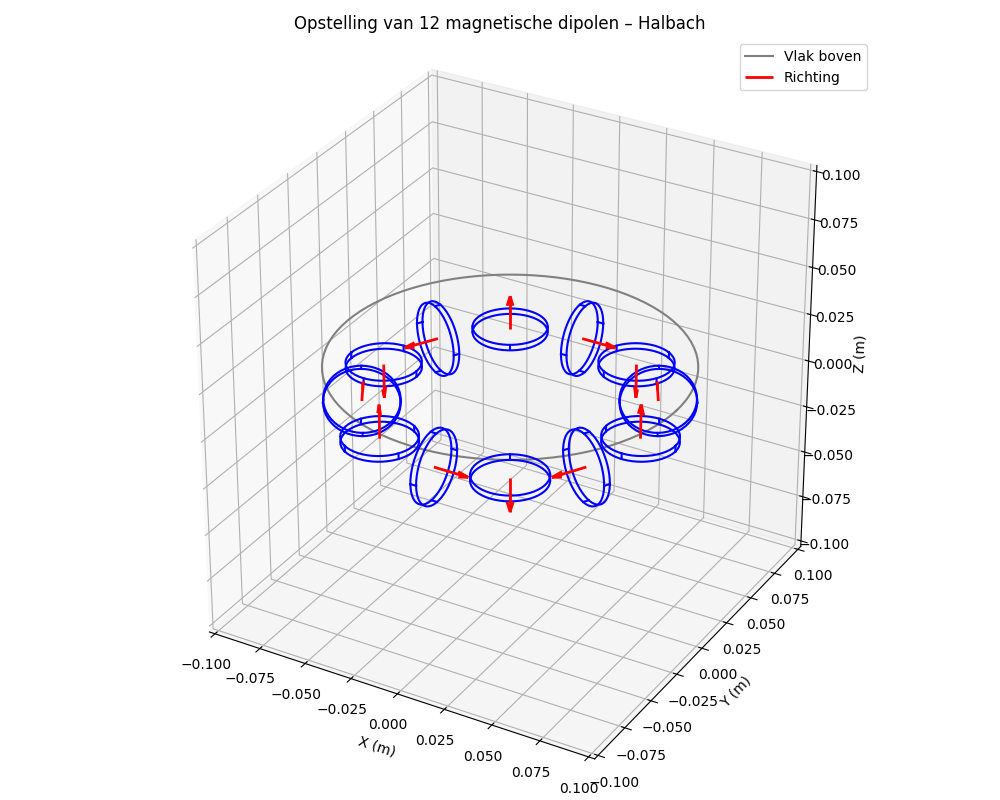

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════
#  CONSTANTEN
# ═══════════════════════════════════════════════════════════

mu0 = 4 * np.pi * 1e-7          # permeabiliteit vacuum [H/m]

# ═══════════════════════════════════════════════════════════
#  PARAMETERS
# ═══════════════════════════════════════════════════════════

# Magneten
N    = 12                        # aantal magneten
rmag = 18e-3                     # straal magneet [m]
hmag = 3e-3                      # hoogte magneet [m]
n_magneet = 10                        # dipool-steekpunten per schijf
Br   = 1.265                     # remanentie N35~N45 [T]
p    = 3                         # Halbach harmonische

# Afgeleid
zmag = hmag / 2                  # halve hoogte [m]
Amag = np.pi * rmag**2           # oppervlakte magneet [m²]
r    = N * rmag / np.pi          # ringstraal [m]

# Configuratie
CONFIGURATIES = {0: "Halbach", 1: "Parallel"}
configuratie  = 0
conf          = CONFIGURATIES[configuratie]

# Meetvlakken
n_flux  = 40
breedte = r *2 + rmag*2
z_boven =  0.02                  # [m]
z_onder = -0.02                  # [m]

# ═══════════════════════════════════════════════════════════
#  COÖRDINATENSTELSELS
# ═══════════════════════════════════════════════════════════

def cilindrisch(theta):
    """Eenheidsvectoren van het cilindrisch coördinatenstelsel."""
    r_hat   = np.array([ np.cos(theta), np.sin(theta), 0])
    phi_hat = np.array([-np.sin(theta), np.cos(theta), 0])
    z_hat   = np.array([0, 0, 1])
    return r_hat, phi_hat, z_hat


def Lokaalstelsel(theta, conf, p):
    """
    Geeft (nu_hat, s_hat, t_hat):
      nu_hat — magnetisatierichting
      t_hat  — eerste as van het magneetvlak
      s_hat  — tweede as van het magneetvlak (loodrecht op nu en t)
    """
    r_hat, phi_hat, z_hat = cilindrisch(theta)
    alpha = p * theta

    if conf == "Halbach":
        nu_hat = np.sin(alpha) * phi_hat + np.cos(alpha) * z_hat
        t_hat  = r_hat
        s_hat  = np.cross(nu_hat, t_hat)

    elif conf == "Parallel":
        nu_hat = -z_hat
        t_hat  = phi_hat
        s_hat  = r_hat

    return nu_hat, s_hat, t_hat

# ═══════════════════════════════════════════════════════════
#  GEOMETRIE – steekpunten en meetvlakken
# ═══════════════════════════════════════════════════════════

def maak_vlak_cirkel(breedte, z_vlak, n=40, x0=0, y0=0):
    """
    Roosterpunten binnen een cirkel met diameter `breedte` op hoogte `z_vlak`.
    """
    r_max = breedte / 2
    xs = np.linspace(-r_max + x0, r_max + x0, n)
    ys = np.linspace(-r_max + y0, r_max + y0, n)
    dx, dy = xs[1] - xs[0], ys[1] - ys[0]

    return [
        (np.array([xi, yi, z_vlak]), dx, dy)
        for xi in xs for yi in ys
        if (xi - x0)**2 + (yi - y0)**2 <= r_max**2
    ], xs, ys


def Magnetenpositiecirkel(r, rmag, theta, zmag, nmag, conf, p):
    """
    Verdeelt één magneet over twee schijven van dipool-steekpunten.
    Retourneert lijst van (positie, dx, dy).
    """
    centrum = np.array([r * np.cos(theta), r * np.sin(theta), 0])
    nu_hat, s_hat, t_hat = Lokaalstelsel(theta, conf, p)

    dipoolposities = []
    for z_schijf in (+zmag, -zmag):
        schijf, *_ = maak_vlak_cirkel(rmag * 2, z_schijf, nmag)
        for lokaal, dx, dy in schijf:
            punt = centrum + lokaal[0]*t_hat + lokaal[1]*s_hat + lokaal[2]*nu_hat
            dipoolposities.append((punt, dx, dy))

    return dipoolposities


# ═══════════════════════════════════════════════════════════
#  Bouw dipolen
# ═══════════════════════════════════════════════════════════

def bouw_dipolen_arrays(conf, p):
    """Geeft alle dipool-posities en momenten als NumPy arrays — (M,3) elk."""
    punten, m_vecs = [], []
    for i in range(N):
        theta    = 2 * np.pi * i / N
        posities = Magnetenpositiecirkel(r, rmag, theta, zmag, n_magneet, conf, p)
        m_vec    = moment(theta, conf, p, len(posities))
        for magpunt, *_ in posities:
            punten.append(magpunt)
            m_vecs.append(m_vec)
    return np.array(punten), np.array(m_vecs)   # (M,3), (M,3)



# ═══════════════════════════════════════════════════════════
#  magnetisch moment en B-veld
# ═══════════════════════════════════════════════════════════

def moment(theta, conf, p, n_punten):
    """Magnetisch dipool-moment per punt."""
    nu_hat, *_ = Lokaalstelsel(theta, conf, p)
    V_per_punt = (Amag * 2 * zmag) / n_punten
    moment =  (Br * V_per_punt / mu0) * nu_hat
    return moment


def dipool_B(mag, R):
    """B-veld van één magnetische dipool op afstandsvector R [T]."""
    norm_R = np.linalg.norm(R)
    if norm_R < 1e-10:
        return np.zeros(3)
    Rdak = R / norm_R
    Bveld =  mu0 / (4 * np.pi * norm_R**3) * (3 * np.dot(mag, Rdak) * Rdak - mag)
    return Bveld

def Bveld(rpunt, punten, m_vecs):
    """Totaal B-veld op punt `rpunt` — volledig gevectoriseerd."""
    R      = rpunt - punten                             # (M,3)
    norm_R = np.linalg.norm(R, axis=1)                 # (M,)
    masker = norm_R > 1e-10
    R, m_vecs, norm_R = R[masker], m_vecs[masker], norm_R[masker]

    Rdak   = R / norm_R[:, np.newaxis]                 # (M,3)
    mdotR  = np.sum(m_vecs * Rdak, axis=1)             # (M,)
    schaal = mu0 / (4 * np.pi * norm_R**3)             # (M,)

    B_per  = schaal[:, np.newaxis] * (3 * mdotR[:, np.newaxis] * Rdak - m_vecs)
    return B_per.sum(axis=0)                           # (3,)

# ═══════════════════════════════════════════════════════════
#  FLUX²-INTEGRAAL
# ═══════════════════════════════════════════════════════════

def flux_kwadraat(meetpunten, conf, p):
    """Integreert Bz² over het vlak — maatstaf voor liftkracht [T²·m²]."""
    punten, m_vecs = bouw_dipolen_arrays(conf, p)      # ← één keer voorberekend
    return sum(
        Bveld(rpunt, punten, m_vecs)[2]**2 * dx * dy
        for rpunt, dx, dy in meetpunten
    )

# ═══════════════════════════════════════════════════════════
#  BEREKENINGEN
# ═══════════════════════════════════════════════════════════

vlak_boven, *_ = maak_vlak_cirkel(breedte, z_boven, n_flux)
vlak_onder, *_ = maak_vlak_cirkel(breedte, z_onder, n_flux)


# ═══════════════════════════════════════════════════════════
#  VISUALISATIE
# ═══════════════════════════════════════════════════════════

def plot_vlak(ax, z_vlak, straal, color='grey', label=''):
    hoeken = np.linspace(0, 2 * np.pi, 100)
    ax.plot(straal * np.cos(hoeken), straal * np.sin(hoeken),
            np.full(100, z_vlak), color=color, label=label)


def plot_magneet_cilinder(ax, centrum, theta, rmag, zmag, color='blue'):
    nu_hat, s_hat, t_hat = Lokaalstelsel(theta, conf, p)
    hoeken = np.linspace(0, 2 * np.pi, 50)

    for teken in (+1, -1):
        cirkel = np.array([
            centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + teken*zmag*nu_hat
            for a in hoeken
        ])
        ax.plot(cirkel[:, 0], cirkel[:, 1], cirkel[:, 2], color=color)

    for a in np.linspace(0, 2*np.pi, 5)[:-1]:
        boven = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat + zmag*nu_hat
        onder = centrum + rmag*np.cos(a)*t_hat + rmag*np.sin(a)*s_hat - zmag*nu_hat
        ax.plot([boven[0], onder[0]], [boven[1], onder[1]], [boven[2], onder[2]], color=color)


fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

plot_vlak(ax, z_boven, breedte / 2, color='grey', label='Vlak boven')
# plot_vlak(ax, z_onder, breedte / 2, color='gray',  label='Vlak onder')

for i in range(N):
    theta   = 2 * np.pi * i / N
    centrum = np.array([r * np.cos(theta), r * np.sin(theta), 0])
    nu_hat, *_ = Lokaalstelsel(theta, conf, p)

    plot_magneet_cilinder(ax, centrum, theta, rmag, zmag)
    ax.quiver(*centrum, *nu_hat, length=rmag, color='red',
              linewidth=2, label='Richting' if i == 0 else "")

bereik = 1.5 * r
ax.set_box_aspect([1, 1, 1])
ax.set_xlim3d(-bereik, bereik)
ax.set_ylim3d(-bereik, bereik)
ax.set_zlim3d(-bereik, bereik)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen – {conf}')
ax.legend()
plt.tight_layout()
plt.show()



In [ ]:
# Resolutie Magneet
n_magneet = 8

# Resolutie Flux
n_flux  = 8



print("flux_kwadraat boven, Parallel:", flux_kwadraat(vlak_boven, "Parallel", p))
print("flux_kwadraat onder, Parallel:", flux_kwadraat(vlak_onder, "Parallel", p))
print("flux_kwadraat boven,", conf, ":", a)
print("flux_kwadraat onder,", conf, ":", flux_kwadraat(vlak_onder, conf, p))

flux_kwadraat boven, Parallel: 7.71940523060736e-06
flux_kwadraat onder, Parallel: 7.71940523060736e-06
flux_kwadraat boven, Halbach : 8.443531969569046e-06
flux_kwadraat onder, Halbach : 1.9716507061516794e-05


[np.float64(6103.192150651254)]


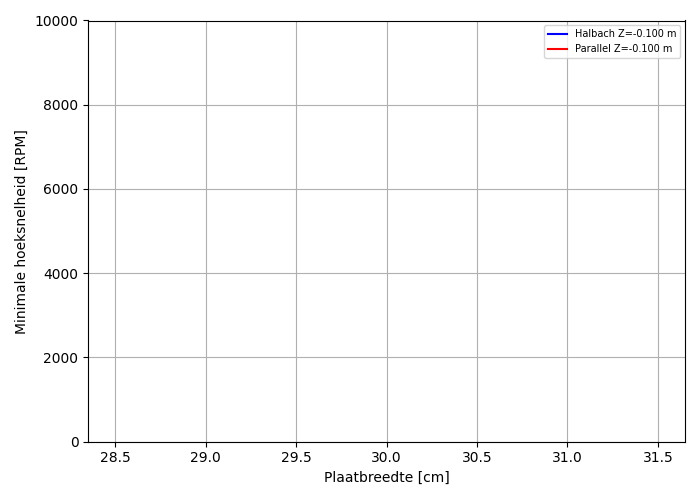

In [25]:
# Resolutie
n_magneet = 8
n_flux    = 8

# ── Constanten ───────────────────────────────────────────────
sigma = 6e7       # elektrische geleiding [S/m]
rho_m = 8960      # dichtheid koper [kg/m³]
g     = 9.81      # valversnelling [m/s²]
t     = 0.003     # plaatdikte [m]

# ── Parameters ───────────────────────────────────────────────
breedte_vals = np.linspace(0.3, 0.3, 1)
breedte_cm   = breedte_vals * 100
z_plaat      = np.linspace(-0.1, -0.1, 1)

# ── Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))



for cfg, kleur in [("Halbach", "blue"), ("Parallel", "red")]:
    for Z in z_plaat:
        RPM_vals = []
        for w in breedte_vals:
            vlak      = maak_vlak_cirkel(w, Z, n_flux)[0]
            a = 10%flux_kwadraat(vlak, cfg, p) 
            Phi2      = a  # ∫ Bz² dA  [T²·m²]
            Bz_rms    = np.sqrt(Phi2 / w**2)          # kwadratisch gemiddelde Bz [T]

            if Bz_rms > 1e-6:
                omega = np.sqrt((rho_m * g) / (sigma * t * Bz_rms**2))
                RPM   = omega * 60 / (2 * np.pi)
            else:
                RPM   = np.nan

            RPM_vals.append(RPM)

        ax.plot(breedte_cm, RPM_vals, color=kleur,
                label=f"{cfg} Z={Z:.3f} m")


print(RPM_vals)
# ── Opmaak ───────────────────────────────────────────────────
ax.set_xlabel("Plaatbreedte [cm]")
ax.set_ylabel("Minimale hoeksnelheid [RPM]")
ax.set_ylim(0, 10000)
ax.legend(fontsize=7)
ax.grid(True)
plt.tight_layout()
plt.show()

Om te bepalen bij welke rotatiesnelheid de Halbach-array een koperen plaat kan laten
levitieren, wordt het evenwicht tussen liftkracht en zwaartekracht opgesteld:

  ω_min = sqrt( ρ_m · g / (σ · t · <Bz²>) )

Uit de grafiek volgt dat bij Z = 5 cm een minimum bereikt wordt rond w ≈ 7 cm,
met ω_min ≈ 230 rad/s ≈ 2200 RPM. Dit is haalbaar met een standaard BLDC-motor
en toont aan dat levitatie met deze opstelling demonstreerbaar is.

Bij grotere plaat (w > 10 cm) neemt ω_min weer toe: de plaat steekt buiten het
effectieve veldgebied van de array (diameter 2r = 6,8 cm), waardoor <Bz²> daalt.
Bij kleinere plaat mist een deel van de flux het plaatoppervlak.
Het optimum ligt dus rond w ≈ 2r.

Bij grotere hoogte Z neemt ω_min sterk toe door de exponentiële veldafval,
en worden de curves buiten het plotvenster (> 1000 rad/s) geclipped.